<a href="https://colab.research.google.com/github/yaneladata/A-B-Testing-Optimizacion-de-Landing-Page-para-E-commerce/blob/main/S9_Version_Student_Proyecto_Landing_Experiment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Experimento A/B en página de inicio

El objetivo de este proyecto es evaluar un **experimento A/B** realizado en una página de inicio (landing page) con versiónes **A y B** para apoyar una **decisión de negocio basada en datos**.

---

El archivo `landing_experiment.csv` contiene información de usuarios expuestos a dos versiones de la página de inicio (landing page) dentro del experimento A/B. Incluye región, dispositivo, fuente de tráfico, tipo de usuario, conversión y gasto.

El análisis sigue una lógica clara y progresiva:

1. 🔍 Explorar y validar los datos.

2. 💰 Comparar el **gasto promedio** por usuario entre la página A y B.

3. 🎯 Comparar la **tasa de conversión** entre la página A y B.

4. 🌐 Revisar **la relación entre la fuente de tráfico y la conversión**.

5. 👤 Revisar **la relación entre el tipo de usuario y la conversión**.

6. 📈 **Visualizar los resultados**: Respalda tus conclusiones mediante gráficos claros.

Se aplican **puebas estadísticas apropiados** para comparar las páginas y **recomendar qué versión es mejor**, justificando la decisión con datos.

## 🧩 Paso 1: Cargar y validar los datos

### 1.1 Carga de datos y vista rápida

In [ ]:
# importar librerías.
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency, ttest_ind
from statsmodels.stats.proportion import proportions_ztest

In [ ]:
# cargar archivo
df = pd.read_csv('/datasets/landing_experiment.csv')

**Vista previa e información general del conjunto de datos**

In [ ]:
# mostrar las primeras 5 filas
df.head(5)

,user_id,date,landing,region,dispositivo,traffic_source,user_type,converted,gasto
0,26f3052e-8500-44ea-8fff-06de65258abb,2026-01-01,A,Norte,Mobile,Email,Recurrente,1,38.08
1,92378c09-4bbf-40c7-945e-82b84f392d22,2026-01-23,A,Occidente,Mobile,Organic,Nuevo,0,0.00
2,a4397360-40e5-45d6-a7ff-dcb4da2c9a1f,2026-01-01,B,Centro,Mobile,Organic,Nuevo,0,0.00
3,7ca3a26f-1e6c-44aa-9b09-b8cb01112956,2026-01-22,A,Centro,Mobile,Ads,Nuevo,0,0.00
4,8dc9593b-5b9c-479d-848b-a99493920419,2026-01-16,A,Sur,Mobile,Organic,Nuevo,0,0.00


In [ ]:
# información general
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   user_id         40000 non-null  object 
 1   date            40000 non-null  object 
 2   landing         40000 non-null  object 
 3   region          40000 non-null  object 
 4   dispositivo     40000 non-null  object 
 5   traffic_source  40000 non-null  object 
 6   user_type       40000 non-null  object 
 7   converted       40000 non-null  int64  
 8   gasto           40000 non-null  float64
dtypes: float64(1), int64(1), object(7)
memory usage: 2.7+ MB


 El dataset no presenta valores ausentes. Para este análisis no se requiere hacer cambios en el tipo de datos de las columnas.


**Descripción del conjunto de datos**

El dataset contiene las siguientes columnas:

- `user_id` — Identificador único del usuario
- `date` — Fecha en la que el usuario fue expuesto a la página
- `landing` — Versión de la página mostrada al usuario
- `region` — Región geográfica del usuario
- `dispositivo` — Tipo de dispositivo utilizado por el usuario
- `traffic_source` — Canal por el que llegó el usuario
- `user_type` — Tipo de usuario según historial previo
- `converted` — Indica si el usuario realizó una conversión
- `gasto` — Monto gastado por el usuario (0 si no convirtió)


### 1.2 Análisis exploratorio y revisión de calidad de datos

Se identifican las variables clave del experimento A/B y se valida que estén bien definidas, completas y que sean consistentes.


 **Variable `user_id`**  
 Verificar usuarios únicos

In [ ]:
df["user_id"].describe()

count                                    40000
unique                                   40000
top       ed29335e-aeef-4cab-ac56-308359bb943e
freq                                         1
Name: user_id, dtype: object

 **Variable `date`**  
Explorar rango de fechas

In [ ]:
# Resumen estadístico
df["date"].describe()

count          40000
unique            28
top       2026-01-24
freq            1512
Name: date, dtype: object

In [ ]:
# Identificar rango temporal del experimento
print("Fecha mínima:", df["date"].min())
print("Fecha máxima:", df["date"].max())

Fecha mínima: 2026-01-01
Fecha máxima: 2026-01-28


**Variable `gasto` (numérica)**

In [ ]:
# Resumen estadístico
df["gasto"].describe()

count    40000.000000
mean         9.325554
std         25.667986
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max        303.680000
Name: gasto, dtype: float64

In [ ]:
# Resumen estadístico de usuarios que se convirtieron
df["converted"].describe()

count    40000.00000
mean         0.14265
std          0.34972
min          0.00000
25%          0.00000
50%          0.00000
75%          0.00000
max          1.00000
Name: converted, dtype: float64

 **Variables categóricas**  
 Verificar categorías esperadas del experimento ( A y B).

In [ ]:
# Explorar variables categóricas y cómo se distribuyen
variables_categoricas = ["landing", "region", "dispositivo", "traffic_source","user_type"]
for col in variables_categoricas:
    print("\nConteo de categorías:")
    print(df[col].value_counts())


Conteo de categorías:
B    20018
A    19982
Name: landing, dtype: int64

Conteo de categorías:
Norte        11166
Centro        9613
Sur           8039
Occidente     6398
Oriente       4784
Name: region, dtype: int64

Conteo de categorías:
Mobile     24829
Desktop    15171
Name: dispositivo, dtype: int64

Conteo de categorías:
Organic     17987
Ads         11935
Email        6123
Referral     3955
Name: traffic_source, dtype: int64

Conteo de categorías:
Nuevo         26033
Recurrente    13967
Name: user_type, dtype: int64


No se encontraron errores en las variables categóricas. Todas las columnas tienen valores esperados.


## 💰 Paso 2: Comparar el gasto promedio por usuario (página A vs B)

Se evalua si existen diferencias estadísticamente significativas en el gasto promedio de los **usuarios que se convirtieron en clientes** entre la página A y la página B, para identificar qué versión genera **mayor valor económico** para el negocio.


In [ ]:
# Gasto por versión
gasto_A = df[(df["landing"]== "A") & (df["converted"] ==1)]
gasto_B = df[(df["landing"]== "B") & (df["converted"] ==1)]

# Verificar cantidad de datos que tiene cada grupo
len(gasto_A), len(gasto_B)

(2512, 3194)

In [ ]:
print("Gasto promedio página A:", gasto_A["gasto"].mean())
print("Gasto promedio página B:", gasto_B["gasto"].mean())

Gasto promedio página A: 61.0865724522293
Gasto promedio página B: 68.74536005009392


### Prueba t-test

**Hipótesis:**
- **Hipótesis nula (H₀):** El gasto pomedio por usuario es igual en la página A y en la página B.
- **Hipótesis alternativa (H₁):** El gasto pomedio por usuario es diferente en la página A y en la página B.

In [ ]:
# Aplicar prueba
t_stat, p_value = ttest_ind(gasto_A["gasto"], gasto_B["gasto"])


# Visualizar resultados
print(f"Estadístico : {t_stat}")
print(f"Valor p: {p_value}")

Estadístico : -9.36563589591332
Valor p: 1.0635288333792346e-20


### 📝 Conclusión e interpretación

**Decisión:**  
El valor p_value es < 0.05 por lo que rechazamos la hipótesis nula.

**Interpretación de negocio:**  
El signo negativo en el valor estadístico indica que el gasto promedio del la página A(61.09) es menor que el de la página B(68.75).



## 📈 Paso 3: Comparar la tasa de conversión entre la página A y B

Se evalua si existen difere]ncias estadísticamente significativas en la **tasa de conversión** entre la página A y B, con el fin de identificar qué versión genera **mayor número de usuarios convertidos**.

### Prueba z de Proporciones

**Hipótesis:**
- **Hipótesis nula (H₀):** La tasa de conversión de la página A es igual que en la página B
- **Hipótesis alternativa (H₁):** La tasa de conversión de la página A es diferente  que en la página B

In [ ]:
# Número de usuarios convertidos por página
conversiones = df.groupby("landing")["converted"].sum()

# Total de usuarios por página
totales = df.groupby("landing")["converted"].count()
exitos = [conversiones["A"], conversiones["B"]]
observaciones = [totales["A"], totales["B"]]
print("Usuarios convertidos por página:\n", exitos)
print("\nTotal de usuarios por página:\n", observaciones)


Usuarios convertidos por página:
 [2512, 3194]

Total de usuarios por página:
 [19982, 20018]


In [ ]:
# Aplicar prueba
z_stat, p_value = proportions_ztest(exitos, observaciones)


# Visualizar resultados
print(f"Estadístico : {z_stat}")
print(f"Valor p: {p_value}")

Estadístico : -9.677362674655983
Valor p: 3.7629765627523803e-22


### 📝 Conclusión e interpretación

**Decisión:**  
El valor p_value es < 0.05 por lo que rechazamos la hipótesis nula

**Interpretación de negocio:**  
 El signo negativo en el valor estadístico indica que la tasa de conversión de la página A(12.6%) es menor que el de la página B(15.9%), eso representa aproximadamente 1,320 usuarios adicionales convertidos.



## 🔗 Paso 4: Revisar la relación entre la fuente de tráfico y la conversión

Se analiza si existe una **asociación estadísticamente significativa** entre la **fuente de tráfico** (`traffic_source`) y la **conversión** (`converted`), para identificar qué canales generan más conversiones.

### Prueba chi2
**Hipótesis:**
- **Hipótesis nula (H₀):** La conversión es independiente del canal por el cual el usuario llegó
- **Hipótesis alternativa (H₁):** La conversión depende del canal por el cual el usuario llegó

In [ ]:
# Aplicar prueba
tabla = pd.crosstab(df["traffic_source"], df["converted"])
chi2_contingency(tabla)
chi2_stat, p_value, dof, expected = chi2_contingency(tabla)
print(f" Estadistico chi_cuadrado: {chi2_stat: .3f}")
print(f"Valor P: {p_value:.3f}")
print(f"Grados de Libertad: {dof}")
print("\n Frecuencias esperadas:")
print(expected)


 Estadistico chi_cuadrado:  8.662
Valor P: 0.034
Grados de Libertad: 3

 Frecuencias esperadas:
[[10232.47225  1702.52775]
 [ 5249.55405   873.44595]
 [15421.15445  2565.84555]
 [ 3390.81925   564.18075]]


In [ ]:

tabla_prop = tabla.div(tabla.sum(axis=1), axis=0)
print(tabla_prop)


converted              0         1
traffic_source                    
Ads             0.852618  0.147382
Email           0.850073  0.149927
Organic         0.862123  0.137877
Referral        0.861188  0.138812


### 📝 Conclusión e interpretación


**Decisión:**  
Se rechaza la hipótesis nula, hay asociación entre canal de usuario(traffic_source) y conversión(converted)

**Interpretación de negocio:**  
Con base en un chi2_test de independencia, encontramos evidencia estadística de que la conversión(converted) esta asociada al canal de usuario(traffic_source). La diferencia entre el mejor(email) y peor (organic) canal es de solo ~1.2% de diferencia. Este resultado se basa en una muestra de usuarios y no implica causalidad directa ni evalua si esta diferencia justifica decisiones diferenciadas desde una perspectiva de negocio.


## 👤 Paso 5: Revisar la relación entre el tipo de usuario y la conversión

Se analiza si existe una **asociación estadísticamente significativa** entre el **tipo de usuario** (`user_type`) y la **conversión** (`converted`), entendiendo que un usuario recurrente puede haber visitado antes sin necesariamente convertirse en cliente en esta ocasión.

El objetivo es identificar qué perfiles muestran mayor probabilidad de conversión dentro del contexto analizado.

### Prueba Chi2

**Hipótesis:**
- **Hipótesis nula (H₀):** La conversión es independiente del tipo de usuario
- **Hipótesis alternativa (H₁):** La conversión es dependiente del tipo de usuario

In [ ]:
# Aplicar prueba
tabla = pd.crosstab(df["user_type"], df["converted"])
chi2_contingency(tabla)
chi2_stat, p_value, dof, expected = chi2_contingency(tabla)
print(f" Estadistico chi_cuadrado: {chi2_stat: .3f}")
print(f"Valor P: {p_value:.3f}")
print(f"Grados de Libertad: {dof}")
print("\n Frecuencias esperadas:")
print(expected)



 Estadistico chi_cuadrado:  0.513
Valor P: 0.474
Grados de Libertad: 1

 Frecuencias esperadas:
[[22319.39255  3713.60745]
 [11974.60745  1992.39255]]


In [ ]:
tabla_prop = tabla.div(tabla.sum(axis=1), axis=0)
print(tabla_prop)


converted          0         1
user_type                     
Nuevo       0.856413  0.143587
Recurrente  0.859096  0.140904


### 📝 Conclusión e interpretación


**Decisión:**  
No Se rechaza la hipótesis nula,no hay evidencia sufieciente de  asociación entre tipo de usuario(user_type) y conversión(converted)

**Interpretación de negocio:**  
Con base en un chi2_test de independencia, no encontramos evidencia estadística de que la conversión(converted) esta asociada al tipo de usuario(user_type). La diferencia entre el tipo de usuario nuevo y tipo de usuario recurrente es de solo ~0.273% de diferencia. Este resultado se basa en una muestra de usuarios y no implica causalidad directa ni evalua si esta diferencia justifica decisiones diferenciadas desde una perspectiva de negocio.

## 📊 Paso 6: Visualizar los resultados de variables categóricas

Se explora visualmente la relación entre variables categóricas (`traffic_source` y `user_type`) y la conversión, mostrando para cada categoría:
- la cantidad absoluta de usuarios que convirtieron y no convirtieron,
- la proporción de usuarios que convirtieron y no convirtieron.

Esto permite analizar tanto el impacto en volumen como la efectividad relativa de cada categoría y reforzar los resultados obtenidos en las pruebas estadísticas.

### Relación entre la fuente de tráfico y la conversión

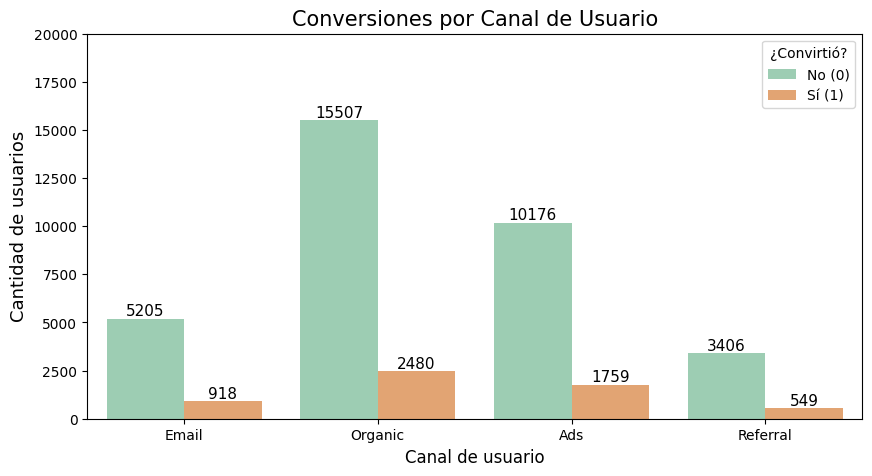

In [ ]:
#Gráfico de barras agrupadas
plt.figure(figsize = (10,5))
ax = sns.countplot(data = df, x = "traffic_source", hue = "converted", palette = ["#95D5B2", "#F4A261"])
for bar in ax.patches:
    height = bar.get_height()
    ax.text(x=bar.get_x() + bar.get_width()/2,
           y = height,
           s = height,
           ha ="center",
           va = "bottom",
           fontsize = 11)

plt.title("Conversiones por Canal de Usuario", fontsize = 15)
plt.xlabel("Canal de usuario", fontsize = 12)
plt.ylabel("Cantidad de usuarios", fontsize = 13)
plt.ylim(0,20000)
plt.legend(title='¿Convirtió?', labels=['No (0)', 'Sí (1)'])
plt.show()


Este gráfico muestra la cantidad de usuarios que convirtieron y no convirtieron según el canal de adquisición. Organic concentra el mayor volumen de usuarios (17,987; 44,97% del total), seguido de Ads (11,935; 29,84%), Email (6,123; 15,31%) y Referral, con la participación más baja (3,955; 9,89%). En términos absolutos, el volumen de usuarios que no convirtieron es mayor en Organic (15,507) que en el resto de los canales, lo cual es esperable dado su mayor volumen total y no indica una tasa de conversión más baja. Al aplicar una prueba chi-cuadrado de independencia, obtuvimos un valor p=0.034, por lo que se rechaza la hipótesis nula: existe una asociación estadísticamente significativa entre canal y conversión. Sin embargo, dado que la diferencia máxima entre canales es de apenas 1.2 pp(Email 14.99% vs. Organic 13.79%), esta significancia no se traduce en una diferencia con valor accionable.

In [ ]:

tabla_traf=pd.crosstab(df["traffic_source"], df["converted"])
tabla_prop_ts=tabla_traf.div(tabla_traf.sum(axis=1), axis=0) *100
print(tabla_prop_ts)

converted               0          1
traffic_source                      
Ads             85.261835  14.738165
Email           85.007349  14.992651
Organic         86.212264  13.787736
Referral        86.118837  13.881163


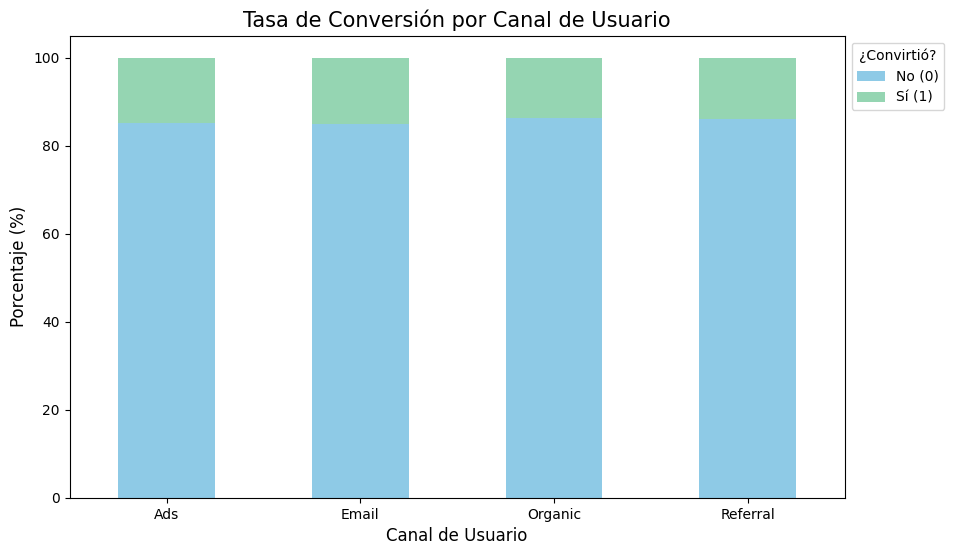

In [ ]:
#Gráfico de barras apiladas
tabla_prop_ts.plot(kind='bar', stacked=True, figsize=(10, 6), color=["#8ecae6", "#95d5b2"])
plt.title('Tasa de Conversión por Canal de Usuario', fontsize=15)
plt.xticks(rotation=0)
plt.ylabel('Porcentaje (%)', fontsize=12)
plt.xlabel('Canal de Usuario', fontsize=12)
plt.legend(title='¿Convirtió?', labels=['No (0)', 'Sí (1)'], loc='upper left', bbox_to_anchor=(1, 1))
plt.show()

Este gráfico muestra la distribución porcentual de conversión (Sí/No) para cada canal de adquisición de usuarios: Ads, Email, Organic y Referral. Las tasas de conversión son similares entre los cuatro canales, oscilando en un rango de 1,2 puntos porcentuales (pp): Email (14,99%) y Ads (14,74%) presentan las tasas más altas, mientras que Organic (13,79%) y Referral (13,88%) muestran las más bajas. Al aplicar una prueba chi-cuadrado de independencia, obtuvimos un valor p=0,034, por lo que se rechaza la hipótesis nula: existe una asociación estadísticamente significativa entre canal y conversión. No obstante, dado el tamaño de muestra (n=40,000) y que la diferencia máxima entre canales es de apenas 1,2 pp, esta significancia no se traduce en una diferencia con valor accionable. Por ello, el canal de tráfico no debería considerarse un criterio prioritario para segmentar estrategias de conversión, y probablemente sea más relevante evaluarlo en combinación con otras variables (ej. dispositivo, región) que de forma aislada.


### Relación entre el tipo de usuario y la conversión

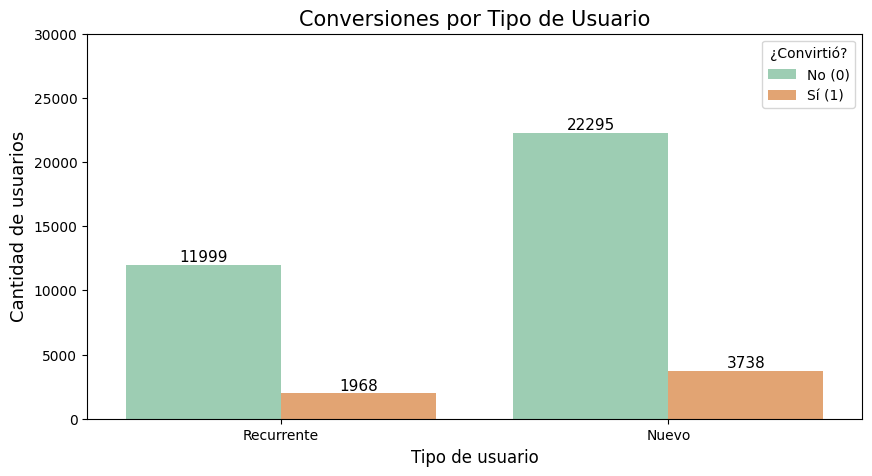

In [ ]:
#Gráfico de barras agrupadas
plt.figure(figsize = (10,5))
ax = sns.countplot(data = df, x = "user_type", hue = "converted", palette = ["#95D5B2", "#F4A261"])
for bar in ax.patches:
    height = bar.get_height()
    ax.text(x=bar.get_x() + bar.get_width()/2,
           y = height,
           s = height,
           ha ="center",
           va = "bottom",
           fontsize = 11
)
plt.title("Conversiones por Tipo de Usuario", fontsize = 15)
plt.xlabel("Tipo de usuario", fontsize = 12)
plt.ylabel("Cantidad de usuarios", fontsize = 13)
plt.ylim(0,30000)
plt.legend(title='¿Convirtió?', labels=['No (0)', 'Sí (1)'])
plt.show()

Este gráfico muestra la cantidad de usuarios que convirtieron y no convirtieron según el tipo de usuario. El tipo de usuario nuevo concentra la mayoría del volumen total (26,033 usuarios, 65.1%), mientras que el tipo recurrente representa una participación menor (13,967 usuarios, 34.9%). En términos absolutos, el volumen de usuarios que no convirtieron es mayor en el tipo nuevo (22,295) que en el recurrente (11,999), lo cual es esperable dado su mayor volumen total y y sugiere —a primera vista— que no hay diferencia de comportamiento entre ambos grupos. La tasa de conversión entre ambos tipos de usuario es muy similar (nuevo: 14.36%, recurrente: 14.09%), con una diferencia mínima de apenas 0.27 puntos porcentuales (pp). Al aplicar una prueba chi-cuadrado de independencia, obtuvimos un valor p de 0.474, por lo que no se rechaza la hipótesis nula (la conversión es independiente del tipo de usuario). Esto indica que el tipo de usuario (nuevo vs. recurrente) no es un factor relevante para explicar la conversión, y no debería usarse como criterio de segmentación en estrategias orientadas a mejorar la tasa de conversión o retención. Aunque el volumen de usuarios nuevos es considerablemente mayor, esta diferencia de volumen no se traduce en una diferencia significativa —ni estadística ni prácticamente relevante— en su comportamiento de conversión.

In [ ]:
tabla_type=pd.crosstab(df["user_type"], df["converted"])
tabla_prop_type=tabla_type.div(tabla_type.sum(axis=1), axis=0)*100
print(tabla_prop_type)

converted           0          1
user_type                       
Nuevo       85.641301  14.358699
Recurrente  85.909644  14.090356


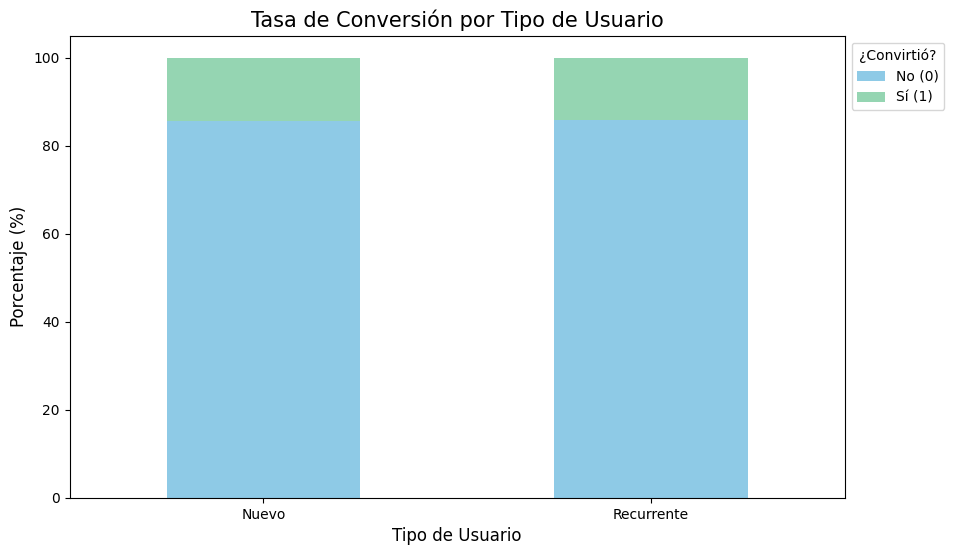

In [ ]:
#Gráfico de barras apiladas
tabla_prop_type.plot(kind='bar', stacked=True, figsize=(10, 6), color=["#8ecae6", "#95d5b2"])
plt.title('Tasa de Conversión por Tipo de Usuario', fontsize=15)
plt.xticks(rotation=0)
plt.ylabel('Porcentaje (%)', fontsize=12)
plt.xlabel('Tipo de Usuario', fontsize=12)
plt.legend(title='¿Convirtió?', labels=['No (0)', 'Sí (1)'], loc='upper left', bbox_to_anchor=(1, 1))
plt.show()

Este gráfico muestra la tasa de conversión por tipo de usuario, independientemente del volumen total. La diferencia en la tasa de conversión entre tipos de usuario (nuevo: 14.36%, recurrente: 14.09%) es mínima, de apenas 0.27 puntos porcentuales (pp). Al aplicar una prueba chi-cuadrado de independencia, obtuvimos un valor p de 0.474, por lo que no se rechaza la hipótesis nula (la conversión es independiente del tipo de usuario). No encontramos evidencia estadística de que la conversión (converted) esté asociada al tipo de usuario (user_type). Por lo tanto, no se recomienda diseñar estrategias de marketing diferenciadas por tipo de usuario, ya que ambos segmentos convierten de forma prácticamente igual.

## 🧩 Paso 7. Insight Ejecutivo para Stakeholders

Se traducen los hallazgos del análisis del experimento A/B en conclusiones accionables para el negocio, enfocadas en **versión de página, conversión, gasto promedio, canales de tráfico y tipo de usuario**.

**Preguntas a responder:**  
- ¿Qué página genera mayor conversión y gasto promedio?  
- ¿Qué canales de tráfico son más efectivos para generar conversiones?  
- ¿Existen diferencias significativas según el tipo de usuario?  
- ¿Qué recomendaciones se pueden tomar para optimizar la estrategia de marketing?


---

### 🌟 Insight Ejecutivo basado en el Experimento A/B

#### 🔍 **Comparación de página (A vs B)**  

**Gasto promedio por usuario que convirtió:**
- El gasto promedio fue de $61.09 en la Página A y $68.75 en la Página B, una diferencia de $7.66 a favor de B.
- La prueba t arrojó un estadístico t=-9.37 y un valor p=1.06×10⁻²⁰ (p<0.05).
- **Interpretación:**
- Se rechaza la hipótesis nula. Existe una diferencia estadísticamente significativa en el gasto promedio entre ambas páginas: los usuarios que convierten en la Página B gastan significativamente más que los que convierten en la Página A.
<br>

**Tasa de conversión:**
- La tasa de conversión fue de 12.57% en la Página A (2,512 de 19,982 usuarios) y 15,96% en la Página B (3,194 de 20,018 usuarios), una diferencia de 3.38 puntos porcentuales a favor de B.
- La prueba z arrojó un estadístico z=-9.68 y un valor p=3.76×10⁻²² (p<0.05).
- **Interpretación:**
- Se rechaza la hipótesis nula. Existe una diferencia estadísticamente significativa en la tasa de conversión entre ambas páginas: la Página B convierte una proporción significativamente mayor de usuarios que la Página A.

---

#### 📊 **Segmentación por fuente de tráfico**
-  Ningún canal muestra una ventaja accionable sobre los demás. Las tasas de conversión por canal son similares, con una diferencia máxima de 1.2 puntos porcentuales: Email (14,99%) y Ads (14,74%) presentan las tasas más altas, mientras que Organic (13,79%) y Referral (13,88%) muestran las más bajas. La prueba chi-cuadrado de independencia arrojó un valor p=0.034 (p<0.05).
- **Interpretación:**
- Se rechaza la hipótesis nula: existe una asociación estadísticamente significativa entre canal de tráfico y conversión. Sin embargo, dado que la diferencia máxima entre canales es de apenas 1.2 puntos porcentuales, esta significancia no se traduce en una diferencia con valor accionable; por lo que se sugiere que el canal de tráfico no debería considerarse un criterio prioritario para segmentar estrategias de conversión

 ---

#### 📊 **Segmentación por tipo de usuario**
-  La tasa de conversión fue de 14.36% para usuarios nuevos y 14.09% para usuarios recurrentes, una diferencia mínima de apenas 0.27 puntos porcentuales. La prueba chi-cuadrado de independencia arrojó un valor p=0.474 (p>0.05).
- **Interpretación:**
- No se rechaza la hipótesis nula: la conversión es independiente del tipo de usuario. Aunque el volumen de usuarios nuevos es considerablemente mayor, esto no se traduce en una diferencia estadísticamente significativa en su comportamiento de conversión; se sugiere que el tipo de usuario no debería usarse como criterio de segmentación en estrategias de conversión.

---

Las visualizaciones usadas respaldan los resultados estadísticos de pasos anteriores.

---

#### 💡 **Recomendaciones de negocio:**
- Se sugiere migrar todo el tráfico a la Página B. Convierte mejor (Página B: 15.96% vs. Página A: 12.57%, +3.38 pp) y genera más gasto por usuario (Página B: 68.75 vs. Página A: 61.09, +7.66), y ambas diferencias son estadísticamente significativas (p<0.001 en los dos casos). Solo con estos resultados, estamos hablando de un impacto estimado de más de 66,000 adicionales en ingresos sobre la base de usuarios analizada (682 usuarios adicionales convertidos en B × 68.75 de gasto promedio, más 2 512 usuarios de A × 7.66 de gasto adicional por usuario ≈ 66 129).  Dado que el experimento corrió solo 28 días, se recomienda un despliegue gradual (por ejemplo, escalando del 25% al 100% del tráfico en incrementos, monitoreando conversión y gasto en cada etapa) en lugar de una migración inmediata al 100%, para confirmar que el efecto se sostiene antes de comprometer todo el tráfico.
-  Se recomienda no enfocar esfuerzos en segmentar por canal de tráfico o tipo de usuario — ninguno hace una diferencia real en la conversión. El canal mostró una diferencia estadísticamente significativa (p=0.034), pero mínima en la práctica (solo 1.2 pp entre el mejor y el peor canal), y el tipo de usuario ni siquiera mostró asociación (p=0.474, diferencia de 0.27 pp). Es mejor invertir ese esfuerzo en seguir optimizando la experiencia de la página (como el cambio de A a B) o explorar otras variables como región o dispositivo antes de descartar la segmentación por completo.
  

#### 💡 **Limitaciones:**
- No sabemos si el efecto es sostenible en el tiempo. El experimento corrió solo 28 días (1-28 de enero), un periodo breve y potencialmente afectado por patrones estacionales propios de ese mes (por ejemplo, menor gasto post-fiestas de fin de año, o mayor gasto por bonos/aguinaldos, dependiendo del comportamiento del consumidor). No se cuenta con datos de otros meses para determinar en qué dirección podría sesgar esto los resultados, por lo que no se puede descartar que la diferencia observada esté subestimada o sobreestimada respecto a un período "normal" del año. A esto se suma el posible efecto "novedad" común en A/B testing: los usuarios reaccionan distinto a un diseño nuevo simplemente por ser nuevo, y ese efecto se diluye con el tiempo. Los $7.66 y los 3.38 puntos porcentuales podrían reducirse una vez que B deje de ser "la novedad" o al evaluarse en otros periodos del año.
#### 💡 **Próximos pasos:**
- Monitorear conversión y gasto promedio semana a semana tras el despliegue completo, para confirmar si el efecto se mantiene, crece o decae.
- Analizar región y dispositivo como variables de segmentación aún no evaluadas en este estudio, para completar el panorama de qué factores influyen realmente en la conversión.
